# **Module 4: Social Media Event Detection (NLP with BERT/KeyBERT, Public Tweet Data, Project Pipeline)**

# **Overview**
This module leverages a public Twitter/crisis/disaster dataset (API-free simulation of real social streams) and applies a transformer-based model (KeyBERT) for event/incident keyword extraction (e.g., accident, protest, blockage).

# **Pipeline Output:**
Detected event(s) per post (timestamp, city, event keyword) are exported as a CSV for downstream integration with adaptive routing and traffic-light control in your urban traffic AI pipeline.
_________________________________________________________________
# **Key Steps**


1.Download and prepare a CSV of crisis/disaster tweets.

2.Extract a demonstration batch.

3.Clean and preprocess tweet text.

4.Run BERT-based event/keyword extraction

5.Annotate timestamp and (if possible) city.

6.Export detected event alerts to CSV.

7.Visualize event/trend results.



# 1. Data Setup
We'll use your Sandy (Hurricane Sandy) public tweets dataset, focusing on the most relevant columns: tweet, text_no_rt, choose_one, perhaps any timestamp/city columns if available.

We'll restructure a DataFrame for the pipeline (assume CSV already loaded as df).

In [ ]:
import pandas as pd

# Suppose your dataset is loaded as
df = pd.read_csv("/content/a146281.csv")

# But you provided in-memory data. Let's select and rename columns for workflow:
df = df.rename(columns={
    'text_no_rt': 'text',
    # add timestamp/city column renaming here if you have such columns!
})

# Optional: generate fake timestamp if none is present
from datetime import datetime, timedelta
if 'timestamp' not in df.columns:
    base = datetime(2012, 10, 28, 12, 0)
    df['timestamp'] = [base + timedelta(minutes=idx*10) for idx in range(len(df))]

# (If you have a city/location field, adapt for use in location attribution below)
print(df[['text', 'timestamp']].sample(5))

                                                  text           timestamp
90   RT @mpoppel: BREAKING -- About 6200 customers ... 2012-10-29 03:00:00
84   Collapsed crane 57th St. NYC. #Sandy http://t.... 2012-10-29 02:00:00
131  More #Sandy impact: Bellevue NYC's flagship pu... 2012-10-29 09:50:00
108  UPDATE: Construction crane collapses in midtow... 2012-10-29 06:00:00
73   U.N. Security Council relocates due to storm d... 2012-10-29 00:10:00


# 2. TEXT PREPROCESSING
Clean up for BERT input: Remove RT/URLs/hashtags/mentions/special chars.

In [ ]:
import re

def clean(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"#\S+", "", text)   # Remove hashtags
    text = re.sub(r"@\S+", "", text)   # Remove mentions
    text = re.sub(r"\s+", " ", text)   # Collapse whitespace
    text = re.sub(r"[^\w\s,.]", "", text) # Remove any non-alphanumerics except basic punctuation
    return text.strip()

df['clean_text'] = df['text'].apply(clean)
print(df['clean_text'].sample(5))

122    Barack Obama to visit New Jersey after Superst...
136    Checking out US under attack Sandy kills 39 as...
55           Bloomberg 34 of a million in without power.
118    Couple of NYC photos from Reddit showing the e...
11     Nearly All Of Weston Without Power After Hurri...
Name: clean_text, dtype: object


# 3. KEYBERT SETUP

In [ ]:
# Install if missing:
!pip install keybert sentence-transformers --quiet

from keybert import KeyBERT
kw_model = KeyBERT('all-MiniLM-L6-v2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.8 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# 4. KEYWORD/EVENT EXTRACTION

In [ ]:
def extract_event_keywords(text, n=4):
    keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1,2), stop_words='english', top_n=n)
    return [kw for kw,score in keywords]

df['keywords'] = df['clean_text'].apply(lambda x: extract_event_keywords(x, 4))
print(df[['clean_text','keywords']].sample(5))

                                            clean_text  \
85   Mayor on May be the worst storm we have ever e...   
113  UPDATE At least 33 deaths blamed on Sandy Supe...   
76   RT UPDATE Outages in have reached more than 19...   
13   The four zoos in NYC say not a single animal w...   
157  Hurricane Sandy is expected to cause up to 10 ...   

                                              keywords  
85   [worst storm, mayor worst, storm experienced, ...  
113  [33 deaths, superstorm sandy, sandy superstorm...  
76   [update outages, outages reached, outages, rt ...  
13     [zoos nyc, animal injured, zoos, single animal]  
157  [insured losses, hurricane sandy, billion insu...  


In [ ]:
!pip install keybert sentence-transformers --quiet

# 5. CITY/LOCATION & TIMESTAMP TAGGING
If you have an explicit city column, use it. If not, infer via keyword matching.

In [ ]:
cities = ['new york','nyc','manhattan','brooklyn','queens','staten island','new jersey','nj','boston','philadelphia']

def detect_city(text):
    text = text.lower()
    found = [c.title() for c in cities if c in text]
    return found[0] if found else None

df['city'] = df['clean_text'].apply(detect_city)
df['datetime'] = pd.to_datetime(df['timestamp'], errors='coerce')

# 6. EVENT ALERT CREATION & EXPORT
We'll select critical events and export for integration.

In [ ]:
# Define what constitutes a critical event keyword (lowercase!)
CRITICAL_EVENTS = set([
    "dead", "death", "casualties", "injured", "blocked", "flood", "fire", "crane collapse", "power", "damaged",
    "destruction", "destroyed", "collapsed", "evacuate", "emergency", "subway", "closure", "crash", "stranded"
])

def filter_event_keywords(keywords):
    # Simplistically: Keep only keywords that contain any target substring
    for kw in keywords:
        for word in CRITICAL_EVENTS:
            if word in kw:
                return kw
    return None

df['event_keyword'] = df['keywords'].apply(filter_event_keywords)
alerts_df = df[df['event_keyword'].notnull()][['datetime','city','event_keyword','clean_text']]
alerts_df.to_csv("social_event_alerts_v2.csv", index=False)
print(alerts_df.head(10))

              datetime        city       event_keyword  \
0  2012-10-28 12:00:00        None           28 deaths   
1  2012-10-28 12:10:00    New York         homes power   
3  2012-10-28 12:30:00        None          death toll   
4  2012-10-28 12:40:00        None     flooding subway   
8  2012-10-28 13:20:00        None  collection damaged   
10 2012-10-28 13:40:00         Nyc     collapsed crane   
11 2012-10-28 13:50:00        None        weston power   
12 2012-10-28 14:00:00        None          death toll   
13 2012-10-28 14:10:00         Nyc      animal injured   
14 2012-10-28 14:20:00  New Jersey           deaths ny   

                                           clean_text  
0   28 deaths due to Hurricane Sandy  Charlotte ta...  
1   Sandy kills 50 people nationwide 18 were New Y...  
3   Sandy death toll climbs millions remain withou...  
4   Extensive flooding in all subway tunnels says ...  
8   We are worried about the documents historical ...  
10  NYC firefighters look

# 7. VISUALIZE EVENT/TRAND DISTRIBUTIONS

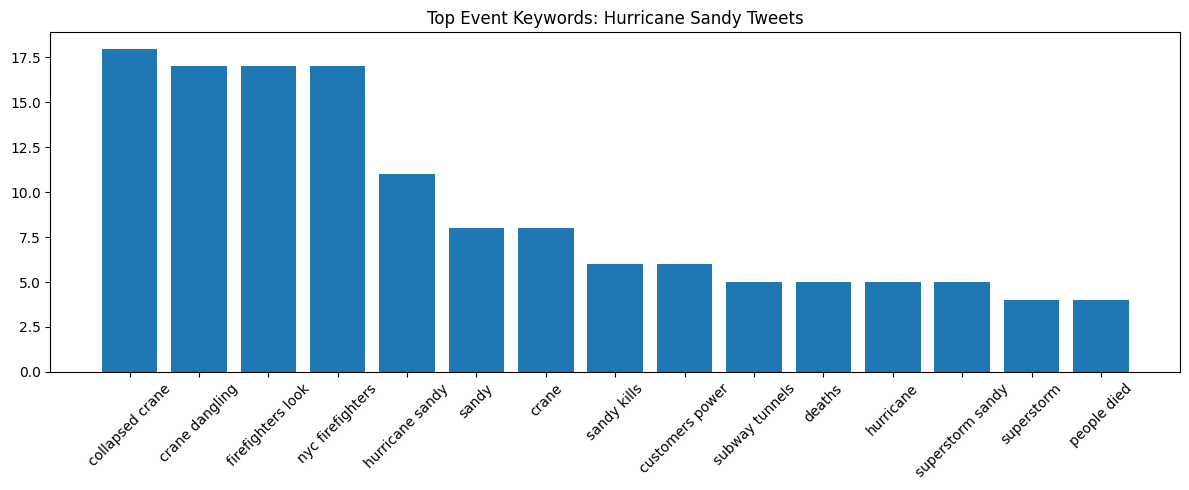

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

all_keywords = [kw for kws in df['keywords'] for kw in kws]
kw_counts = Counter(all_keywords)
top_keys = kw_counts.most_common(15)
plt.figure(figsize=(12,5))
plt.bar([kw for kw,_ in top_keys],[c for _,c in top_keys])
plt.xticks(rotation=45)
plt.title("Top Event Keywords: Hurricane Sandy Tweets")
plt.tight_layout()
plt.show()

# 8. SYSTEM RESPONSE SIMULATION

In [ ]:
def simulate_traffic_system_response(event, city):
    event = event or ""
    if any(k in event for k in ["dead","casualt","injured"]):
        return f"[🚨] Casualty event in {city or 'unknown'}: Emergency resources alert!"
    if any(k in event for k in ["flood","blocked","closure"]):
        return f"[🚦] Road disruption in {city or 'unknown'}: Activate rerouting."
    if "fire" in event or "explosion" in event:
        return f"[🚒] Fire/Explosion in {city or 'unknown area'}: Green corridor for emergency."
    if any(k in event for k in ["power"]):
        return f"[⚡] Power outage in {city or 'unknown'}: Notify grid and traffic systems."
    if "crane collapse" in event or "collapse" in event:
        return f"[🚧] Infrastructure collapse in {city or 'unknown'}: Block routes, deploy safety."
    return "[OK] No system action required."

for idx, row in alerts_df.head(12).iterrows():
    print(row['datetime'], simulate_traffic_system_response(row['event_keyword'], row['city']))

2012-10-28 12:00:00 [OK] No system action required.
2012-10-28 12:10:00 [⚡] Power outage in New York: Notify grid and traffic systems.
2012-10-28 12:30:00 [OK] No system action required.
2012-10-28 12:40:00 [🚦] Road disruption in unknown: Activate rerouting.
2012-10-28 13:20:00 [OK] No system action required.
2012-10-28 13:40:00 [🚧] Infrastructure collapse in Nyc: Block routes, deploy safety.
2012-10-28 13:50:00 [⚡] Power outage in unknown: Notify grid and traffic systems.
2012-10-28 14:00:00 [OK] No system action required.
2012-10-28 14:10:00 [🚨] Casualty event in Nyc: Emergency resources alert!
2012-10-28 14:20:00 [OK] No system action required.
2012-10-28 14:50:00 [OK] No system action required.
2012-10-28 15:10:00 [⚡] Power outage in unknown: Notify grid and traffic systems.


**End of Module 4:**

A robust, pipelinable social-NLP event detection system ready for smart urban traffic control projects.